In [1]:
# Some basic imports
import numpy as np
import pandas as pd

import json, re, time
import logging, requests
import itertools

from pathlib import Path
from typing import Optional
from dataclasses import dataclass, asdict
from urllib.parse import urlencode, urljoin

# Useful 'constants'
REPLAY_DIR = Path('./replays/gen9-randombattle')
USER_DIR = Path('./../data/users')

In [17]:
ratings_data = []

for item in USER_DIR.iterdir() : 
    if (item.is_file() and item.name[0]!='.') : 
        with open(item, 'r') as file: 
            user_json = json.load(file)
        rating = user_json.get('ratings')
        if rating.get('gen9randombattle') != None :
            ratings_data.append(rating.get('gen9randombattle'))
        else : 
            print("No rating for %s" % item.stem)
            continue
    elif (item.name[0]=='.') : continue
    else : print("invalid file"); continue

No rating for crosby89
No rating for sehreensbf
No rating for tokinadapurple
No rating for dugtrioisbroken
No rating for bigtitbitch
No rating for t3amskyf4n
No rating for ls1234
No rating for nitromegamer007
No rating for lannna
No rating for sdiazch
No rating for conor3d
No rating for mrcar5
No rating for docwidek
No rating for umbreonsguardian


In [22]:
df = pd.DataFrame(ratings_data)

In [22]:
df7 = pd.DataFrame({"a": 1, "b": 2}, index=[0])
new_row = pd.Series({"a": 3, "b": 4})
pd.concat([df7, new_row.to_frame().T], ignore_index=True)

# Plotting

In [27]:
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
# Apply the default theme
sns.set_theme()

In [37]:
df.columns

Index(['elo', 'gxe', 'rpr', 'rprd', 'w', 'l', 'coil'], dtype='str')

Text(0.5, 1.0, 'Counts of Elo scores')

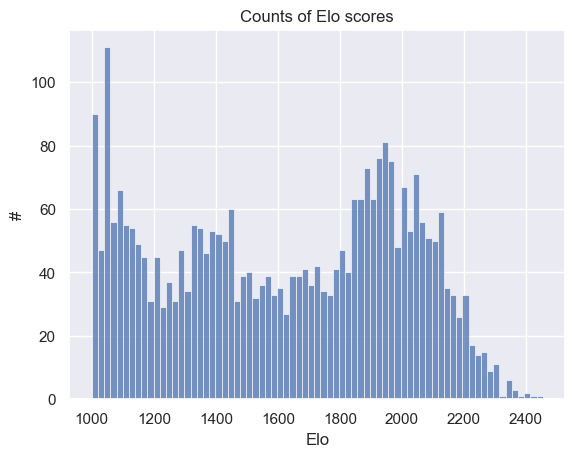

In [60]:
g = sns.histplot(df, x="elo", binwidth=20)
g.set_xlabel("Elo")
g.set_ylabel("#")
g.set_title("Counts of Elo scores")

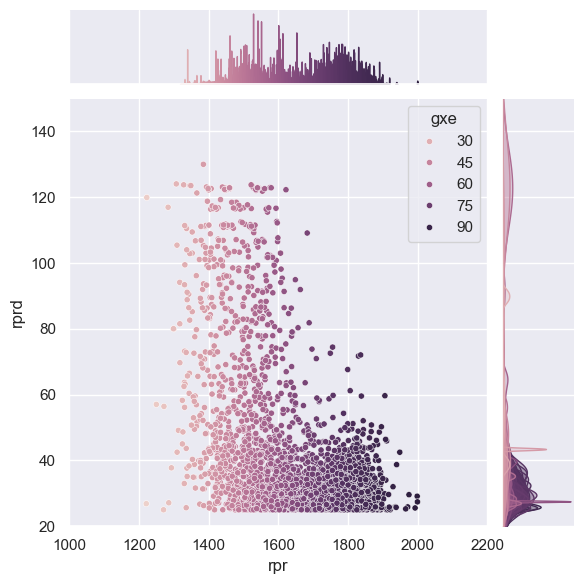

In [66]:
G = sns.jointplot(
    data=df, 
    x="rpr", 
    y="rprd",
    s=20,
    hue='gxe',
    xlim=(1000,2200),
    ylim=(20,150),
)
# G.set_xlabel()
# G.set_ylabel()
# G.set_title(r"Glicko $\sigma$ vs $R$")

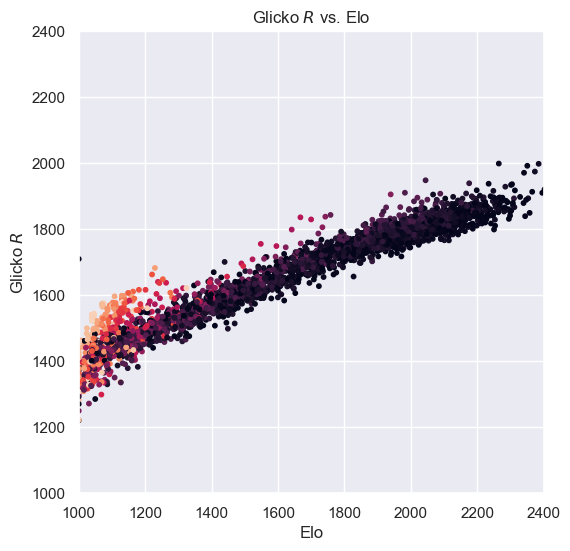

In [74]:
from matplotlib.pyplot import colorbar

fig, ax = plt.subplots(figsize=(6,6))


ax.scatter(df.elo, df.rpr, c=df.rprd, s=10)
ax.set_xlim(1000,2400)
ax.set_ylim(1000,2400)
ax.set_xlabel("Elo")
ax.set_ylabel("Glicko $R$")
ax.set_title("Glicko $R$ vs. Elo")
plt.show()